## **Linear Regression** from scratch using **NumPy**

This notebook builds Linear Regression step by step from scratch, starting from the mathematical formulation to implementing gradient descent and evaluating performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# predict the output for given input and weights
def get_prediction(x, weights, biases):
    prod = x @ weights
    return prod+biases

In [3]:
# randomly intializes weights
def initialize_weights(n_features, n_samples):
    weights = np.random.rand(n_features, 1)
    biases = np.random.rand(1)
    return weights, biases

In [4]:
# calculates MSE loss
def calculate_loss(y_pred, y_true):
    error = y_true - y_pred
    mean_squared_error = np.mean(np.square(error))
    return mean_squared_error

In [5]:
# calculate the gradients
def calculate_gradient(y_pred, y_true, features, weights, biases, n_samples):
    d_weights = (-2/n_samples)*np.sum((y_true-y_pred) * features, axis=0)
    d_biases = (-2/n_samples)*np.sum(y_true-y_pred, axis=0)
    return d_weights, d_biases

In [6]:
# prepare training and test data
def get_train_test_data(csv_file_path):
    df = pd.read_csv(csv_file_path)
    df = df.sample(frac=1).reset_index(drop=True)
    total = len(df)
    train_data = df.iloc[:int(total*0.7)]
    train_data = train_data.drop('Unnamed: 0', axis=1).to_numpy()
    test_data = df.iloc[int(total*0.7):]
    test_data = test_data.drop('Unnamed: 0', axis=1).to_numpy()
    return train_data, test_data

In [7]:
def prepare_input_output_data(csv_path):
    training_data, test_data = get_train_test_data(csv_path)
    
    X_train = training_data[:,0].reshape(-1,1)
    Y_train = training_data[:,1].reshape(-1,1)
    
    X_test = test_data[:,0].reshape(-1,1)
    Y_test = test_data[:,1].reshape(-1,1)
    
    # print("X train shape:", X_train.shape)
    # print("Y train shape:", Y_train.shape)
    # print("X test shape:", X_test.shape)
    # print("Y test shape:", Y_test.shape)
    
    return X_train, Y_train, X_test, Y_test

In [8]:
def plot_line(y_pred):
    idx = X_train[:, 0].argsort()
    plt.scatter(X_train, Y_train)
    plt.plot(X_train[idx], y_pred[idx], color='red')
    plt.show()

In [9]:
def plot_error(costs):
    x = list(range(1, len(costs)+1))
    y = costs
    plt.plot(x, y)
    plt.show()

In [10]:
# plot regression line and the cost curve
def plot_trends(y_pred, costs, X, Y):
    def plot_line(ax, X, Y, y_pred):
        idx = X[:, 0].argsort()
        ax.scatter(X, Y)
        ax.plot(X[idx], y_pred[idx], color='red')
        ax.set_title("Regression Line")

    def plot_error(ax, costs):
        x = list(range(1, len(costs)+1))
        ax.plot(x, costs)
        ax.set_title("Cost vs Iterations")
        
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    
    plot_line(axes[0], X, Y, y_pred)
    plot_error(axes[1], costs)
    
    plt.tight_layout()
    plt.show()

In [11]:
# train the model on trainig data
def train_model(
    X, 
    Y_true, 
    learning_rate:float=0.01, 
    epochs:int=5000, 
    show_plot_interval:int|None=None
):
    n_features = X.shape[1]
    n_samples = X.shape[0]
    weights, biases = initialize_weights(n_features, n_samples)
    
    # print("wieghts shape:", weights.shape)
    # print("biases shape:", biases.shape)
    
    errors =[]
    for i in range(epochs):
        preds = get_prediction(X, weights, biases)
        loss = calculate_loss(preds, Y_true)
        errors.append(loss)
        d_weights, d_biases = calculate_gradient(preds, Y_true, X, weights, biases, n_samples)
        weights -= learning_rate * d_weights
        biases -= learning_rate * d_biases
        if show_plot_interval and i % show_plot_interval == 0:
            print(f"Iteration: {i}")
            plot_trends(preds, errors, X, Y_true)
            print()
    
    plot_trends(preds, errors, X, Y_true)
    
    return {"weights": weights, "biases": biases, "error": errors[-1]}

In [12]:
data_file_path = "/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv"
X_train, Y_train, X_test, Y_test = prepare_input_output_data(data_file_path)

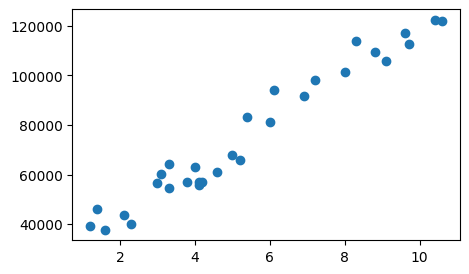

In [13]:
# plot all the data points
def plot_data_points(X, Y):
    plt.figure(figsize=(5, 3))
    plt.scatter(X, Y)
    plt.show()

plot_data_points(np.concatenate((X_train,X_test)), np.concatenate((Y_train,Y_test)))

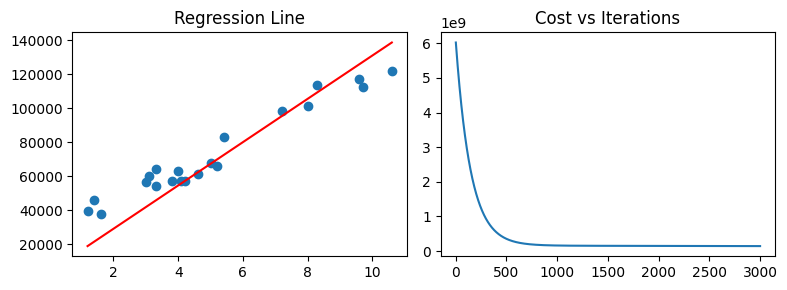

In [14]:
model_info = train_model(
    X_train,
    Y_train,
    learning_rate=0.00005,
    epochs=3000,
    show_plot_interval=None
)

In [15]:
learned_weights = model_info["weights"]
learned_biases = model_info["biases"]
error = model_info["error"]

In [16]:
# learned_weights, learned_biases, error

In [17]:
def plot_regression_line(X, Y, y_pred):
    idx = X[:, 0].argsort()
    plt.figure(figsize=(5,3))
    plt.scatter(X, Y)
    plt.plot(X[idx], y_pred[idx], color='red')
    plt.show()

In [18]:
# calculate R^2 value for given predicted and actual outputs
def calculate_r_square(y_pred, y_true):
    baseline_error = np.mean((y_true - np.mean(y_true))**2)  
    model_error = np.mean((y_true - y_pred)**2)
    r_square = 1 - (model_error/baseline_error)
    return r_square

R^2: 0.8861135269674163


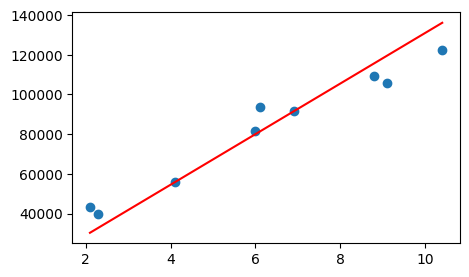

In [19]:
def test_model(X, Y):
    preds_test = get_prediction(X, learned_weights, learned_biases)
    r_square = calculate_r_square(preds_test, Y)
    print(f"R^2: {r_square}")
    plot_regression_line(X_test, Y_test, preds_test)

test_model(X_test, Y_test)

In [20]:
###################################################### END ######################################################